In [177]:
import os
import glob
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf

from PIL import Image

from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os
import glob
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display

from PIL import Image

from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

import warnings
warnings.filterwarnings('ignore')

BASE_DIR = os.getcwd()      # Root DIR 설정
AUDIO_DIR = os.path.join(BASE_DIR, 'audio')     # 오디오 파일이 저장된 루트 폴더
SPEC_DIR = os.path.join(BASE_DIR, 'spectrogram_data')       # 오디오를 이미지로 변환하여 저장할 루트 폴더
SPLIT_DIR = os.path.join(BASE_DIR, 'spectrogram_split')     # CNN 학습용으로 train/val/test 구조로 나누어 저아 루트 폴더
BEST_MODEL_PATH = os.path.join(BASE_DIR, 'cnn_model.keras')        # 최종 학습 모델 저장 경로
TEMP_PREDICT_IMAGE_PATH = os.path.join(BASE_DIR, 'temp_predict_spectrogram.png')   # 신규 예측시 임시로 스펙트로그램 이미지를 저장할 경로

CLASSES = ['Non_Hornet', 'Hornet']

# CNN 입역 이미지 높이
IMG_HEIGHT = 224

# CNN 입력 이미지 너비
IMG_WIDTH = 224

# signal processing 파라미터 설정
SR = 32768          # 샘플링 주파수
DURATION = 2      # 오디오 길이 (초단위)
SAMPLES_PER_TRACK = SR * DURATION   # 1개 오디오 샘플당 기대되는 총 샘플수
N_FFT = 4096        # 엘 스펙트럼그램 생성시, 사용할 FFT 윈도우 길이
HOP_LENGTH = 128    # 프레임 간 hop 크기 (값이 작을수록 시간 해상도 증가)
N_MELS = 128         # mel filter bank 개수 (너무 작으면 정보 깨지고, 너무 크면 이미지 복잡해짐)

BATCH_SIZE = 16
EPOCHS = 20

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

import warnings
warnings.filterwarnings('ignore')

```````````````python
# 실험 A
N_FFT = 4096
HOP_LENGTH = 128
N_MELS = 64

# 실험 B
N_FFT = 4096
HOP_LENGTH = 128
N_MELS = 128

# 실험 C
N_FFT = 2048
HOP_LENGTH = 256
N_MELS = 128
```````````````

# 유효성 검사 및 공통 유틸리티 함수

In [178]:
def ensure_directory_exists(dir_path):
    """
    지정한 디렉토리가 존재하지 않으면 생성
    """
    os.makedirs(dir_path, exist_ok=True)


def validate_audio_directory_structure(audio_dir, classes):
    """
    audio 폴더와 클래스별 하위 폴더가 존재하는지 확인
    """
    if not os.path.exists(audio_dir):
        raise FileNotFoundError(f"[오류] audio 루트 폴더를 찾을 수 없습니다: {audio_dir}")

    for cls in classes:
        class_dir = os.path.join(audio_dir, cls)
        if not os.path.exists(class_dir):
            raise FileNotFoundError(f"[오류] 클래스 폴더가 없습니다: {class_dir}")


def count_audio_files(audio_dir, classes, extensions=("*.wav", "*.mp3")):
    """
    클래스별 오디오 파일 개수를 집계하여 dict 형태로 반환
    (wav + mp3 모두 지원)
    """
    counts = {}
    for cls in classes:
        total_count = 0
        for ext in extensions:
            pattern = os.path.join(audio_dir, cls, ext)
            total_count += len(glob.glob(pattern))
        counts[cls] = total_count
    return counts


def validate_minimum_files_per_class(file_counts, minimum_count=3):
    """
    각 클래스에 최소 개수 이상의 파일이 존재하는지 검증
    """
    for cls, count in file_counts.items():
        if count < minimum_count:
            raise ValueError(
                f"[오류] 클래스 '{cls}'의 파일 수가 너무 적습니다. "
                f"최소 {minimum_count}개 이상 필요하지만 현재 {count}개입니다."
            )


def safe_remove_path(path):
    """
    파일 또는 디렉토리가 존재할 때만 삭제
    """
    if os.path.isdir(path):
        shutil.rmtree(path)
    elif os.path.isfile(path):
        os.remove(path)


def print_section_title(title):
    """
    노트북에서 섹션 구분이 명확하게 보이도록 제목 출력
    """
    print("\n" + "=" * 60)
    print(title)
    print("=" * 60)


데이터 폴더 및 파일 개수 확인
원본 오디오 루트 경로: c:\Users\hoons\OneDrive\바탕 화면\휴먼교육 실습\휴먼 프로젝트\audio
스팩트로그램 저장 경로: c:\Users\hoons\OneDrive\바탕 화면\휴먼교육 실습\휴먼 프로젝트\spectrogram_data
분할 데이터 저장 경로: c:\Users\hoons\OneDrive\바탕 화면\휴먼교육 실습\휴먼 프로젝트\spectrogram_split
        Class  Count
0  Non_Hornet  14185
1      Hornet   2327


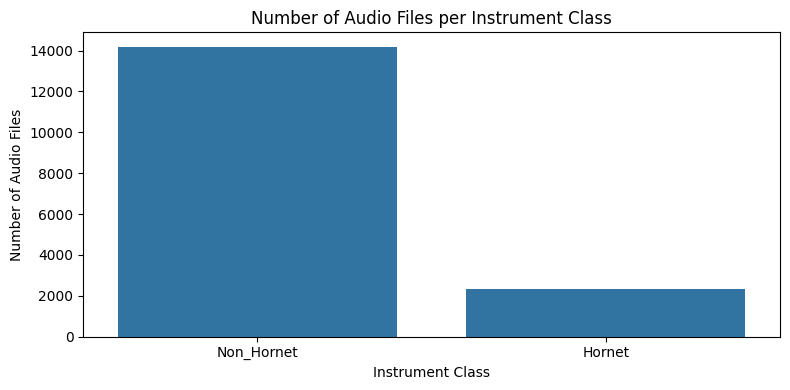

In [179]:
# audio 폴더와 클래스별 하위 폴더가 실제로 존재하는지 검증
validate_audio_directory_structure(AUDIO_DIR, CLASSES)

files_counts = count_audio_files(AUDIO_DIR, CLASSES, extensions=("*.wav", "*.mp3"))

# 각 클래스
validate_minimum_files_per_class(files_counts, minimum_count=3)

file_counts_df = pd.DataFrame(list(files_counts.items()), columns=['Class', 'Count'])

print_section_title('데이터 폴더 및 파일 개수 확인')
print('원본 오디오 루트 경로:', AUDIO_DIR)
print('스팩트로그램 저장 경로:', SPEC_DIR)
print('분할 데이터 저장 경로:', SPLIT_DIR)
print(file_counts_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=file_counts_df, x='Class', y='Count')
plt.title('Number of Audio Files per Instrument Class')
plt.xlabel('Instrument Class')
plt.ylabel('Number of Audio Files')
plt.tight_layout()
plt.show()

# 오디오 로드 함수 정의

In [180]:
def load_audio_file(file_path, sr=SR, duration=DURATION):
    """
    오디오 파일을 모노 신호로 읽고, 지정 길이로 고정한다.

    설계 의도:
    - 모델 입력 일관성을 위해 모든 오디오 길이를 동일하게 맞춘다.
    - 너무 짧은 파일은 zero-padding한다.
    - 너무 긴 파일은 앞부분을 사용한다.
    - 실습/강의 환경에서 mp3 코덱 또는 파일 경로 문제를 조기에 감지할 수 있도록 예외를 명확히 전달한다.
    """

    if not isinstance(file_path, str):
        raise TypeError(f"[오류] file_path는 문자열이어야 합니다. 현재 타입: {type(file_path)}")

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"[오류] 오디오 파일이 존재하지 않습니다: {file_path}")

    valid_exts = [".mp3", ".wav", ".flac", ".ogg", ".m4a"]
    ext = os.path.splitext(file_path)[1].lower()
    if ext not in valid_exts:
        raise ValueError(f"[오류] 지원하지 않는 오디오 확장자입니다: {ext}")

    try:
        y, sr = librosa.load(file_path, sr=sr, mono=True)
    except Exception as e:
        raise RuntimeError(f"[오류] 오디오 로드 실패: {file_path}\n원인: {e}")

    if y is None or len(y) == 0:
        raise ValueError(f"[오류] 오디오 데이터가 비어 있습니다: {file_path}")

    target_length = int(sr * duration)

    if len(y) < target_length:
        pad_width = target_length - len(y)
        y = np.pad(y, (0, pad_width), mode='reflect')
    else:
        y = y[:target_length]

    # 평균 제거
    y = y - np.mean(y)

    # 진폭 정규화
    max_val = np.max(np.abs(y))
    if max_val > 0:
        y = y / max_val

    return y, sr

In [181]:
sample_file = None
sample_class = None

for cls in CLASSES:
    pattern = os.path.join(AUDIO_DIR, cls, '*.wav')
    files = glob.glob(pattern)
    if len(files) > 0:
        sample_file = files[0]
        sample_class = cls
        break
    
if sample_file is None:
    raise FileNotFoundError('[오류] 샘플로 사용할 mp3 파일을 찾지 못했습니다.')

y_sample, sr_sample = load_audio_file(sample_file)

print_section_title('샘플 오디오 정보')
print('샘플 클래스:', sample_class)
print('샘플 파일:', sample_file)
print('샘플링 주파수:', sr_sample)
print('총 샘플 수:', len(y_sample))
print('총 길이(초):', len(y_sample) / sr_sample)


샘플 오디오 정보
샘플 클래스: Non_Hornet
샘플 파일: c:\Users\hoons\OneDrive\바탕 화면\휴먼교육 실습\휴먼 프로젝트\audio\Non_Hornet\output_Bee_0_Bee_0_0000.wav
샘플링 주파수: 32768
총 샘플 수: 65536
총 길이(초): 2.0


# 시각화 정보

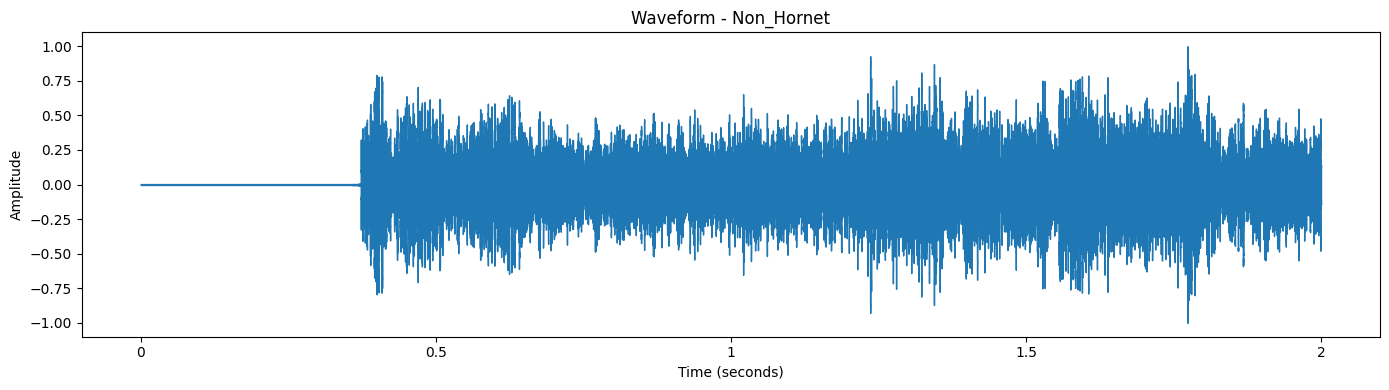

In [182]:
# waveform 시각화

plt.figure(figsize=(14, 4))
librosa.display.waveshow(y_sample, sr=sr_sample)
plt.title(f'Waveform - {sample_class}')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

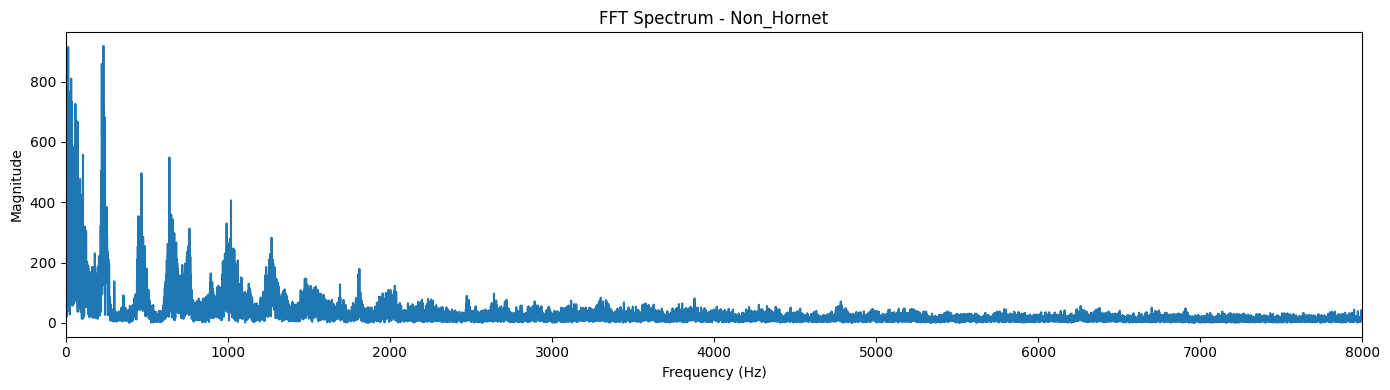

In [183]:
fft_sample = np.fft.fft(y_sample)

magnitude_sample = np.abs(fft_sample)

freq_sample = np.fft.fftfreq(len(magnitude_sample), d=1 / sr_sample)

positive_freq_sample = freq_sample[:len(freq_sample) // 2]
positive_magnitude_sample = magnitude_sample[:len(magnitude_sample) // 2]

plt.figure(figsize=(14, 4))
plt.plot(positive_freq_sample, positive_magnitude_sample)
plt.title(f'FFT Spectrum - {sample_class}')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, 8000)
plt.tight_layout()
plt.show()

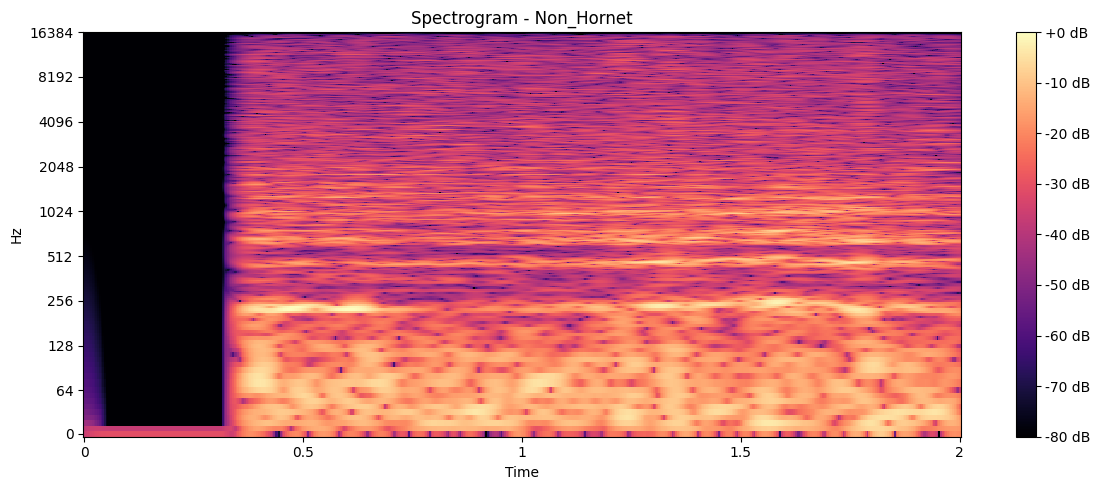

In [184]:
stft_sample = librosa.stft(y_sample, n_fft=N_FFT, hop_length=HOP_LENGTH)

spectrogram_sample = np.abs(stft_sample)

spectrogram_db_sample = librosa.amplitude_to_db(spectrogram_sample, ref=np.max)

plt.figure(figsize=(12, 5))
librosa.display.specshow(
    spectrogram_db_sample,
    sr=sr_sample,
    hop_length=HOP_LENGTH,
    x_axis='time',
    y_axis='log',
    cmap='magma'
)

plt.colorbar(format='%+2.0f dB')
plt.title(f'Spectrogram - {sample_class}')
plt.tight_layout()
plt.show()

# 세로 artifact를 줄이는 증강 세로줄/경계줄 약화

In [185]:
def apply_time_mask(img, max_mask_ratio=0.12):
    """
    시간축(가로축) 일부를 soft하게 가려서 세로줄/경계 의존을 줄인다.
    """
    img = img.copy()
    h, w, c = img.shape

    if w < 10:
        return img

    mask_width = random.randint(1, max(1, int(w * max_mask_ratio)))
    start = random.randint(0, max(0, w - mask_width))

    patch = img[:, start:start + mask_width, :]
    patch_mean = patch.mean()
    patch_std = max(patch.std(), 0.02)

    noise_patch = np.random.normal(
        loc=patch_mean,
        scale=patch_std * 0.3,
        size=patch.shape
    )

    img[:, start:start + mask_width, :] = np.clip(noise_patch, 0, 1)
    return img

In [186]:
def apply_small_time_shift(img, max_shift_ratio=0.08):
    """
    시간축(가로축)으로 살짝 이동시키고,
    빈 공간은 가장자리 값을 복제해 경계 artifact를 줄인다.
    """
    img = img.copy()
    h, w, c = img.shape

    max_shift = max(1, int(w * max_shift_ratio))
    shift = random.randint(-max_shift, max_shift)

    if shift == 0:
        return img

    shifted = np.roll(img, shift=shift, axis=1)

    if shift > 0:
        shifted[:, :shift, :] = img[:, 0:1, :]
    else:
        shifted[:, shift:, :] = img[:, -1:, :]

    return shifted

In [187]:
def apply_random_time_erasing(img, max_erase_ratio=0.10):
    """
    시간축 특정 구간을 지워서 세로 artifact 하나만 보고 맞히지 못하게 한다.
    time masking과 비슷하지만 좀 더 랜덤한 지우기 역할.
    """
    h, w, c = img.shape

    if w < 10:
        return img

    erase_width = random.randint(1, max(1, int(w * max_erase_ratio)))
    start = random.randint(0, max(0, w - erase_width))

    fill_value = img.mean()
    img[:, start:start + erase_width, :] = fill_value
    return img

In [188]:
def apply_frequency_mask(img, max_mask_ratio=0.10):
    """
    주파수축(세로축) 일부를 soft하게 가려서 특정 대역 artifact 의존을 줄인다.
    """
    img = img.copy()
    h, w, c = img.shape

    if h < 10:
        return img

    mask_height = random.randint(1, max(1, int(h * max_mask_ratio)))
    start = random.randint(0, max(0, h - mask_height))

    patch = img[start:start + mask_height, :, :]
    patch_mean = patch.mean()
    patch_std = max(patch.std(), 0.02)

    noise_patch = np.random.normal(
        loc=patch_mean,
        scale=patch_std * 0.3,
        size=patch.shape
    )

    img[start:start + mask_height, :, :] = np.clip(noise_patch, 0, 1)
    return img

In [189]:
def custom_train_preprocessing(img):
    """
    train 전용 spectrogram 이미지 증강
    - 세로 artifact
    - 파일 경계
    - 특정 위치 의존성
    을 줄이는 데 목적이 있다.
    """
    img = img.copy()

    # 확률적으로 적용
    if random.random() < 0.6:
        img = apply_small_time_shift(img, max_shift_ratio=0.08)

    if random.random() < 0.5:
        img = apply_time_mask(img, max_mask_ratio=0.12)

    if random.random() < 0.4:
        img = apply_random_time_erasing(img, max_erase_ratio=0.10)

    if random.random() < 0.3:
        img = apply_frequency_mask(img, max_mask_ratio=0.10)

    return img

# 검은 영역 많은 샘플은 학습에서 제외

In [190]:
def has_too_much_black(img_path, threshold=20, max_black_ratio=0.20):
    """
    저장된 이미지 파일 경로를 받아서
    검은 영역 비율이 너무 높으면 True 반환
    threshold: 0~255 기준
    """
    with Image.open(img_path).convert('RGB') as img:
        arr = np.array(img).astype(np.float32) / 255.0

    threshold = threshold / 255.0
    black_ratio = np.mean(arr < threshold)

    return black_ratio > max_black_ratio

In [191]:
def remove_black_padding(spec, threshold=-75):
    mask = np.mean(spec, axis=0) > threshold

    if np.sum(mask) < 10:
        return spec

    return spec[:, mask]

# 이미지 저장 함수
```python
# N_MELS가 128일 때
# 너무 저주파 쪽 제거, 너무 고주파 쪽 제거, 가운데 핵심 대역 유지
cropped_spec = mel_spec_db[12:96, :]

# 아래쪽을 더 잘라서 사람 목소리 저주파 영향 줄이고, 위쪽도 더 줄여서 고주파 noise 덜 보기
cropped_spec = mel_spec_db[16:88, :]

# N_MELS가 64일 때
cropped_spec = mel_spec_db[6:48, :]
cropped_spec = mel_spec_db[8:44, :]

# 조금 더 강한 crop
# N_MELS=128이면:
cropped_spec = mel_spec_db[16:88, :]

# N_MELS=64: 
cropped_spec = mel_spec_db[8:44, :]

In [192]:
import gc

def save_spectrogram_image(audio_path, save_path, sr=SR, duration=DURATION, apply_spec_aug=False):
    
    save_dir = os.path.dirname(save_path)
    
    if save_dir != '':
        ensure_directory_exists(save_dir)
        
    # 오디오 파일을 로드
    y, sr = load_audio_file(audio_path, sr=sr, duration=duration)

    # 멜 스펙트로그램을 계산한다.
    mel_spec = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        power=2.0
    )

    # dB 단위로 변환한다.
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    
    # 완전 검정 방지 (noise floor 추가)
    mel_spec_db += np.random.normal(0, 1.5, mel_spec_db.shape)

    # dB 하한 고정
    mel_spec_db = np.clip(mel_spec_db, a_min=-80, a_max=None)

    # 0~3000Hz에 해당하는 mel bin만 사용
    mel_freqs = librosa.mel_frequencies(n_mels=N_MELS, fmin=0, fmax=sr/2)

    start_bin = np.searchsorted(mel_freqs, 0)
    end_bin = np.searchsorted(mel_freqs, 4000, side='right')

    start_bin = max(0, start_bin)
    end_bin = min(N_MELS, end_bin)

    cropped_spec = mel_spec_db[:end_bin, :]
    cropped_spec = remove_black_padding(cropped_spec)

    # 훈련용 spectrogram augmentation
    if apply_spec_aug:
        if random.random() < 0.4:
            cropped_spec = apply_time_shift_to_spec(cropped_spec, max_shift_ratio=0.04)

        if random.random() < 0.5:
            cropped_spec = apply_time_mask(cropped_spec, max_mask_ratio=0.06)

        if random.random() < 0.3:
            cropped_spec = apply_random_erasing_to_spec(
                cropped_spec,
                max_time_ratio=0.06,
                max_freq_ratio=0.10
            )
    
    fig = plt.figure(figsize=(4, 4))
    
    librosa.display.specshow(
        cropped_spec,
        sr=sr,
        hop_length=HOP_LENGTH,
        x_axis=None,
        y_axis=None,
        cmap='magma'
    )
    
    plt.axis('off')
    plt.tight_layout(pad=0)
    plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
    plt.close(fig)
    plt.cla()
    plt.clf()

    with Image.open(save_path) as img:
        resized = img.convert('RGB').resize((IMG_WIDTH, IMG_HEIGHT))
        resized.save(save_path)
        resized.close()
        
    # 저장 후 검은 영역 과다 검사
    if has_too_much_black(save_path, threshold=20, max_black_ratio=0.20):
        os.remove(save_path)
        return False
    
    return True

# del y, mel_spec, mel_spec_db, cropped_spec
librosa.cache.clear()
gc.collect()

[Memory(location=None)]: Flushing completely the cache


3351121

# 장치 스타일 증강 함수

In [193]:
def apply_device_style(y, sr=SR):
    """
    장치/마이크/인코딩 차이를 약하게 흉내내는 함수
    - 둘 중 한 클래스만 특정 장치 특징을 갖지 않도록
      양쪽 클래스 모두에 랜덤하게 적용할 수 있게 설계
    """

    y = y.copy()

    # 1) gain 변화
    gain = random.uniform(0.85, 1.15)
    y = y * gain

    # 2) 약한 broadband noise / hiss
    if random.random() < 0.5:
        noise_level = random.uniform(0.0005, 0.003)
        noise = np.random.normal(0, noise_level, size=len(y))
        y = y + noise

    # 3) 저역/고역 강조 흉내: pre-emphasis / de-emphasis 느낌
    if random.random() < 0.5:
        coeff = random.uniform(0.90, 0.98)
        y = np.append(y[0], y[1:] - coeff * y[:-1])

    # 4) 약한 저대역 통과/고대역 손실 흉내
    # resample down-up으로 싸구려 장치/압축 느낌 일부 흉내
    if random.random() < 0.5:
        target_sr = random.choice([8000, 12000, 16000, 22050])
        y_down = librosa.resample(y, orig_sr=sr, target_sr=target_sr)
        y = librosa.resample(y_down, orig_sr=target_sr, target_sr=sr)

        # 길이 보정
        target_len = int(sr * DURATION)
        if len(y) < target_len:
            y = np.pad(y, (0, target_len - len(y)), mode='constant')
        else:
            y = y[:target_len]

    # 5) 약한 clipping/압축 느낌
    if random.random() < 0.3:
        clip_val = random.uniform(0.7, 0.95)
        y = np.clip(y, -clip_val, clip_val)

    # 최종 정규화
    max_val = np.max(np.abs(y))
    if max_val > 0:
        y = y / max_val

    return y

## 임시 wav 저장 후 spectrogram 만드는 공통 함수 추가

In [194]:
def save_augmented_spectrogram(audio_array, save_path, temp_dir, base_name, sr=SR):
    ensure_directory_exists(temp_dir)

    temp_path = os.path.join(temp_dir, f'temp_{base_name}.wav')
    sf.write(temp_path, audio_array, sr)

    ok = save_spectrogram_image(temp_path, save_path)

    if os.path.exists(temp_path):
        os.remove(temp_path)

    return ok

## Non_Hornet용 장치 스타일 증강 함수 추가

In [195]:
def augment_non_hornet_audio(audio_path, sr=SR, duration=DURATION):
    y, _ = load_audio_file(audio_path, sr=sr, duration=duration)
    y = apply_device_style(y, sr=sr)
    return y

# Hornet에 양봉장 배경음 섞는 augmentation 추가
## 배경음 섞기 전용

In [196]:
# 혹시 나중에 파일 경로 기반으로 배경 섞기 테스트할 때 쓸 수도 있음 -> 수정 하지 않고 유지
def mix_with_background(hornet_path, background_pool, sr=32768, bg_gain_range=(0.08, 0.25)):
    y_hornet, _ = librosa.load(hornet_path, sr=sr)
    bg_path = random.choice(background_pool)
    y_bg, _ = librosa.load(bg_path, sr=sr)

    # 길이 맞추기
    if len(y_bg) < len(y_hornet):
        repeat_count = int(np.ceil(len(y_hornet) / len(y_bg)))
        y_bg = np.tile(y_bg, repeat_count)

    y_bg = y_bg[:len(y_hornet)]

    # 정규화
    if np.max(np.abs(y_hornet)) > 0:
        y_hornet = y_hornet / np.max(np.abs(y_hornet))
    if np.max(np.abs(y_bg)) > 0:
        y_bg = y_bg / np.max(np.abs(y_bg))

    bg_gain = random.uniform(bg_gain_range[0], bg_gain_range[1])

    mixed = y_hornet + bg_gain * y_bg

    # clipping 방지
    if np.max(np.abs(mixed)) > 0:
        mixed = mixed / np.max(np.abs(mixed))

    return mixed

## 오디오 배열 y 자체에 배경을 섞음

In [197]:
def mix_audio_with_background(y, background_pool, sr=SR, duration=DURATION, bg_gain_range=(0.08, 0.2)):
    bg_path = random.choice(background_pool)
    y_bg, _ = load_audio_file(bg_path, sr=sr, duration=duration)

    # 배경 정규화
    if np.max(np.abs(y_bg)) > 0:
        y_bg = y_bg / np.max(np.abs(y_bg))

    # 원신호도 정규화
    if np.max(np.abs(y)) > 0:
        y = y / np.max(np.abs(y))

    bg_gain = random.uniform(bg_gain_range[0], bg_gain_range[1])
    mixed = y + bg_gain * y_bg

    if np.max(np.abs(mixed)) > 0:
        mixed = mixed / np.max(np.abs(mixed))

    return mixed

## pitch shift / time stretch / gain / noise 더 넓은 증강용
- gain 변화
    - 거리 차이
    - 마이크 감도 차이
    - 녹음 볼륨 차이
    - 추천 범위: 0.8 ~ 1.2
- 작은 pitch shift
    - 말벌 개체 차이
    - 회전 속도 차이
    - 녹음 조건 차이
    - 추천 범위: -1 ~ +1 semitone 많아도 -2 ~ +2 semitone 정도
    - 너무 크게 하면 말벌이 아니라 다른 생물처럼 들릴 수 있음
- 작은 time stretch
    - 날갯짓 속도 차이
    - 이동 속도 차이
    - 녹음 상황 차이
    - 추천 범위: 0.9 ~ 1.1
    - 구조는 유지하면서 약간 다른 개체처럼 보이게 할 수있음
- background mixing
    - 실제 양봉장 환경 반영
    - 모델이 배경 차이만 보지 않게 함
- 약한 additive noise
    - 녹음 잡음
    - 마이크 hiss
    - 현장 noise

In [198]:
def augment_hornet_audio(audio_path, sr=SR, duration=DURATION, background_pool=None):
    y, _ = load_audio_file(audio_path, sr=sr, duration=duration)

    # 1) gain 변화
    gain = random.uniform(0.85, 1.15)
    y = y * gain

    # 2) 작은 pitch shift
    if random.random() < 0.5:
        n_steps = random.uniform(-1.0, 1.0)
        y = librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)

    # 3) 작은 time stretch
    if random.random() < 0.5:
        rate = random.uniform(0.95, 1.05)
        y = librosa.effects.time_stretch(y, rate=rate)

        target_len = int(sr * duration)
        if len(y) < target_len:
            y = np.pad(y, (0, target_len - len(y)))
        else:
            y = y[:target_len]

    # 4) 약한 잡음 추가
    if random.random() < 0.3:
        noise_level = random.uniform(0.001, 0.004)
        noise = np.random.normal(0, noise_level, size=len(y))
        y = y + noise

    # 5) background mixing
    if background_pool is not None and len(background_pool) > 0 and random.random() < 0.7:
        y = mix_audio_with_background(
            y=y,
            background_pool=background_pool,
            sr=sr,
            duration=duration,
            bg_gain_range=(0.08, 0.2)
        )
        
    # 6) 장치 스타일 증강
    if random.random() < 0.7:
        y = apply_device_style(y, sr=sr)

    # 최종 정규화
    if np.max(np.abs(y)) > 0:
        y = y / np.max(np.abs(y))

    return y

# 전체 오디오 파일 -> Spectogram 이미지 생성
- 배경 다양성 확장:
Non-Hornet 1000~1500
Hornet 500

- 실전형:
Non-Hornet 2000~3000
Hornet 1000 이상

In [199]:
safe_remove_path(SPEC_DIR)
ensure_directory_exists(SPEC_DIR)

print_section_title('오디오 파일을 스펙트로그램 이미지로 변환 중...')

random.seed(42)

# Hornet 샘플의 80%는 Hornet 전용 증강 적용
HORNET_AUG_PROB = 0.8

# Non_Hornet 샘플의 50%는 장치 스타일 증강 적용
NON_HORNET_DEVICE_AUG_PROB = 0.5

MAX_FILES_PER_CLASS = 2000
HALF_FILES = MAX_FILES_PER_CLASS // 2

background_pool = []

TEMP_AUDIO_DIR = os.path.join(BASE_DIR, 'temp_audio_aug')
ensure_directory_exists(TEMP_AUDIO_DIR)

# Non_Hornet 폴더에서 no_bee 파일만 미리 모음
non_hornet_dir = os.path.join(AUDIO_DIR, 'Non_Hornet')
all_non_hornet_files = glob.glob(os.path.join(non_hornet_dir, '*.wav')) + \
                       glob.glob(os.path.join(non_hornet_dir, '*.mp3'))

for f in all_non_hornet_files:
    filename = os.path.basename(f)
    if filename.startswith('output_No_Bee_'):
        background_pool.append(f)

print(f'배경 풀 크기: {len(background_pool)}')

for cls in CLASSES:
    class_audio_dir = os.path.join(AUDIO_DIR, cls)
    class_spec_dir = os.path.join(SPEC_DIR, cls)

    ensure_directory_exists(class_spec_dir)

    # 모든 wav / mp3 파일 가져오기
    audio_files = glob.glob(os.path.join(class_audio_dir, '*.wav')) + \
                  glob.glob(os.path.join(class_audio_dir, '*.mp3'))

    # Non_Hornet은 Bee / No_Bee 반반 샘플링
    if cls == 'Non_Hornet':
        bee_files = []
        no_bee_files = []

        for f in audio_files:
            filename = os.path.basename(f)

            if filename.startswith('output_No_Bee_'):
                no_bee_files.append(f)
            elif filename.startswith('output_Bee_'):
                bee_files.append(f)

        random.shuffle(bee_files)
        random.shuffle(no_bee_files)

        selected_bee = bee_files[:HALF_FILES]
        selected_no_bee = no_bee_files[:HALF_FILES]
        selected_files = selected_bee + selected_no_bee
        random.shuffle(selected_files)

        print(f'{cls}: bee {len(selected_bee)}개 + no_bee {len(selected_no_bee)}개 = 총 {len(selected_files)}개 파일 처리 중...')

        if len(selected_bee) < HALF_FILES:
            print(f'경고: Bee 파일이 부족합니다. 사용 가능 개수 = {len(selected_bee)}')
        if len(selected_no_bee) < HALF_FILES:
            print(f'경고: No_Bee 파일이 부족합니다. 사용 가능 개수 = {len(selected_no_bee)}')

    # Hornet은 무작위 샘플링
    else:
        random.shuffle(audio_files)
        selected_files = audio_files[:HALF_FILES]
        print(f'{cls}: {len(selected_files)}개 파일 처리 중...')

    # 스펙트로그램 저장
    for audio_file in selected_files:
        base_name = os.path.splitext(os.path.basename(audio_file))[0]
        save_path = os.path.join(class_spec_dir, f'{base_name}.png')

        # Hornet: Hornet 전용 증강 + 장치 스타일
        if cls == 'Hornet' and random.random() < HORNET_AUG_PROB:
            augmented_audio = augment_hornet_audio(
                audio_path=audio_file,
                sr=SR,
                duration=DURATION,
                background_pool=background_pool
            )

            save_augmented_spectrogram(
                audio_array=augmented_audio,
                save_path=save_path,
                temp_dir=TEMP_AUDIO_DIR,
                base_name=base_name,
                sr=SR
            )

        # Non_Hornet: 장치 스타일 증강만 일부 적용
        elif cls == 'Non_Hornet' and random.random() < NON_HORNET_DEVICE_AUG_PROB:
            augmented_audio = augment_non_hornet_audio(
                audio_path=audio_file,
                sr=SR,
                duration=DURATION
            )

            save_augmented_spectrogram(
                audio_array=augmented_audio,
                save_path=save_path,
                temp_dir=TEMP_AUDIO_DIR,
                base_name=base_name,
                sr=SR
            )

        # 나머지는 원본
        else:
            save_spectrogram_image(audio_file, save_path)

print('스펙토그램 이미지 생성 완료')


오디오 파일을 스펙트로그램 이미지로 변환 중...
배경 풀 크기: 7110
Non_Hornet: bee 1000개 + no_bee 1000개 = 총 2000개 파일 처리 중...
Hornet: 1000개 파일 처리 중...
스펙토그램 이미지 생성 완료


<Figure size 640x480 with 0 Axes>

# train / val / test 분할 함수
## 장치/원본 소스 단위 분할을 위한 설정
아래 딕셔너리에 "파일명/경로에 들어있는 키워드 : 그룹명" 형태로 추가하면,
같은 그룹(같은 장치/같은 원본 소스) 파일들은 항상 같은 split으로만 들어간다.

예시:
```python
SOURCE_GROUP_KEYWORDS = {
    'devicea': 'device_a',
    'devicesamsungs23': 'device_s23',
    'recorderzoomh1': 'zoom_h1',
    'sourceb': 'source_b',
}
```
주의:
- key 는 소문자로 넣는 것을 권장
- value 는 같은 장치/같은 원본 소스를 대표하는 그룹명
- 파일명뿐 아니라 전체 경로 문자열에서도 검사함

In [200]:
import re

SOURCE_GROUP_KEYWORDS = {
    'source1': 'source_1',
    'source2': 'source_2',
}

USE_SOURCE_GROUP_SPLIT = True


def infer_source_group_key(file_path, class_name=None):
    """
    오디오 파일 경로에서 장치/원본 소스 그룹 키를 추출한다.

    우선순위
    1) SOURCE_GROUP_KEYWORDS에 등록된 키워드 매칭
    2) (fallback) 확장자 제거 파일명 자체를 그룹으로 사용

    반드시 같은 장치/같은 원본 소스 파일들이 같은 그룹명을 반환하도록 맞춰야 한다.
    """
    normalized_path = file_path.replace('\\', '/').lower()
    filename = os.path.splitext(os.path.basename(file_path))[0]
    normalized_filename = filename.lower()

    for keyword, group_name in SOURCE_GROUP_KEYWORDS.items():
        if keyword.lower() in normalized_path or keyword.lower() in normalized_filename:
            return str(group_name)

    # fallback:
    # 그룹 규칙을 아직 정의하지 않았을 때 최소한 동작은 하게 만들지만,
    # 이 상태에서는 사실상 파일 단위 분할과 거의 비슷해질 수 있으므로
    # 실제 사용 전 SOURCE_GROUP_KEYWORDS를 채우는 것을 강하게 권장.
    return normalized_filename


def parse_source_group_from_spec_filename(filename):
    """
    spectrogram 파일명에서 앞쪽에 붙여둔 source group prefix를 복원한다.
    형식: __SRCGROUP__{group_key}__{원래파일명}.png
    """
    base = os.path.splitext(os.path.basename(filename))[0]
    prefix = '__SRCGROUP__'
    sep = '__'

    if base.startswith(prefix) and sep in base[len(prefix):]:
        remain = base[len(prefix):]
        group_key, _ = remain.split(sep, 1)
        return group_key

    # prefix가 없는 예전 파일도 최대한 처리
    return base


def add_source_group_prefix_to_name(base_name, group_key):
    safe_group_key = re.sub(r'[^a-zA-Z0-9_-]+', '_', str(group_key))
    return f'__SRCGROUP__{safe_group_key}__{base_name}'

In [201]:
def split_dataset_to_folders(source_dir, target_dir, classes, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    """
    spectrogram 이미지를 클래스별 train/val/test 폴더 구조로 분할
    같은 장치/같은 원본 소스 그룹은 반드시 하나의 split에만 들어가도록 처리한다.
    """

    # 기존 split 폴더를 삭제
    safe_remove_path(target_dir)

    # 비율의 합이 1인지 검증
    if abs(train_ratio + val_ratio + test_ratio - 1.0) >= 1e-6:
        raise ValueError("[오류] train_ratio + val_ratio + test_ratio의 합은 반드시 1이어야 함")

    for cls in classes:
        class_dir = os.path.join(source_dir, cls)

        # 원본 클래스 이미지가 존재하는지 확인
        if not os.path.exists(class_dir):
            raise FileNotFoundError(f"[오류] spectrogram 클래스 폴더가 없습니다: {class_dir}")

        image_files = glob.glob(os.path.join(class_dir, "*.png"))

        # 클래스별 이미지가 없으면 학습 불가이므로 중단
        if len(image_files) == 0:
            raise ValueError(f"[오류] 클래스 '{cls}'의 spectrogram 이미지가 없습니다.")

        # split별 폴더를 생성
        for split_name in ["train", "val", "test"]:
            ensure_directory_exists(os.path.join(target_dir, split_name, cls))

        # ------------------------------------------------------------
        # 같은 장치 / 같은 원본 소스 그룹끼리 묶기
        # ------------------------------------------------------------
        grouped_files = {}

        for f in image_files:
            filename = os.path.basename(f)
            group_key = parse_source_group_from_spec_filename(filename)

            if group_key not in grouped_files:
                grouped_files[group_key] = []

            grouped_files[group_key].append(f)

        group_items = list(grouped_files.items())
        random.shuffle(group_items)

        n_total = len(image_files)
        target_train = n_total * train_ratio
        target_val = n_total * val_ratio

        train_files, val_files, test_files = [], [], []

        train_count = 0
        val_count = 0

        for group_key, files in group_items:
            # 아직 train 목표치에 못 미치면 train에 배정
            if train_count < target_train:
                train_files.extend(files)
                train_count += len(files)

            # train이 찼고 val 목표치에 못 미치면 val에 배정
            elif val_count < target_val:
                val_files.extend(files)
                val_count += len(files)

            # 나머지는 test
            else:
                test_files.extend(files)

        # 복사 보조 함수
        def copy_files(files, split_name):
            for f in files:
                dst = os.path.join(target_dir, split_name, cls, os.path.basename(f))
                shutil.copy2(f, dst)

        copy_files(train_files, "train")
        copy_files(val_files, "val")
        copy_files(test_files, "test")

        print(f"{cls} -> train:{len(train_files)}, val:{len(val_files)}, test:{len(test_files)}")
        print(f"{cls} 그룹 수 -> train/val/test 기준 전체 {len(group_items)}개 source group")

        # 어떤 group이 어느 split에 들어갔는지 요약 출력
        split_group_summary = {
            "train": sorted({parse_source_group_from_spec_filename(os.path.basename(f)) for f in train_files}),
            "val": sorted({parse_source_group_from_spec_filename(os.path.basename(f)) for f in val_files}),
            "test": sorted({parse_source_group_from_spec_filename(os.path.basename(f)) for f in test_files}),
        }

        print(f"  train groups ({len(split_group_summary['train'])}개): {split_group_summary['train']}")
        print(f"  val groups ({len(split_group_summary['val'])}개): {split_group_summary['val']}")
        print(f"  test groups ({len(split_group_summary['test'])}개): {split_group_summary['test']}")

        overlap_train_val = set(split_group_summary["train"]) & set(split_group_summary["val"])
        overlap_train_test = set(split_group_summary["train"]) & set(split_group_summary["test"])
        overlap_val_test = set(split_group_summary["val"]) & set(split_group_summary["test"])

        if overlap_train_val or overlap_train_test or overlap_val_test:
            raise ValueError(
                f"[오류] 같은 source group이 여러 split에 섞였습니다. "
                f"train∩val={overlap_train_val}, train∩test={overlap_train_test}, val∩test={overlap_val_test}"
            )

In [202]:
def validate_split_dataset(target_dir, classes):
    """
    split 이후 각 train/val/test/class 폴더에 최소 1개 이상의 이미지가 있는지 검증한다.
    또한 source group 누수가 없는지도 같이 확인한다.
    """
    print_section_title("분할 데이터셋 검증")
    split_group_map = {"train": {}, "val": {}, "test": {}}

    for split_name in ["train", "val", "test"]:
        print(f"[{split_name}]")
        for cls in classes:
            class_dir = os.path.join(target_dir, split_name, cls)
            count = len(glob.glob(os.path.join(class_dir, "*.png")))
            print(f"  {cls}: {count}개")
            if count == 0:
                raise ValueError(
                    f"[오류] {split_name}/{cls} 폴더에 이미지가 없습니다. "
                    f"클래스별 샘플 수가 너무 적거나 분할 비율 조정이 필요합니다."
                )

            files = glob.glob(os.path.join(class_dir, "*.png"))
            groups = {parse_source_group_from_spec_filename(os.path.basename(f)) for f in files}
            split_group_map[split_name][cls] = groups
            print(f"    source groups: {sorted(groups)}")

    print_section_title("source group 누수 검증")
    for cls in classes:
        train_groups = split_group_map["train"][cls]
        val_groups = split_group_map["val"][cls]
        test_groups = split_group_map["test"][cls]

        overlap_train_val = train_groups & val_groups
        overlap_train_test = train_groups & test_groups
        overlap_val_test = val_groups & test_groups

        print(f"[{cls}]")
        print(f"  train ∩ val  : {sorted(overlap_train_val)}")
        print(f"  train ∩ test : {sorted(overlap_train_test)}")
        print(f"  val   ∩ test : {sorted(overlap_val_test)}")

        if overlap_train_val or overlap_train_test or overlap_val_test:
            raise ValueError(
                f"[오류] '{cls}' 클래스에서 source group 누수가 발생했습니다."
            )

In [203]:
print_section_title('train / val / test 데이터셋 분할 중...')
split_dataset_to_folders(SPEC_DIR, SPLIT_DIR, CLASSES, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15)
validate_split_dataset(SPLIT_DIR, CLASSES)
print('데이터셋 분할 완료')


train / val / test 데이터셋 분할 중...
Non_Hornet -> train:1394, val:299, test:298
Non_Hornet 그룹 수 -> train/val/test 기준 전체 1991개 source group
  train groups (1394개): ['output_Bee_0_Bee_0_0001', 'output_Bee_1000_Bee_1000_0001', 'output_Bee_1003_Bee_1003_0000', 'output_Bee_1004_Bee_1004_0000', 'output_Bee_1007_Bee_1007_0001', 'output_Bee_1007_Bee_1007_0004', 'output_Bee_100_Bee_100_0004', 'output_Bee_1010_Bee_1010_0001', 'output_Bee_1011_Bee_1011_0004', 'output_Bee_1016_Bee_1016_0000', 'output_Bee_1016_Bee_1016_0001', 'output_Bee_1017_Bee_1017_0001', 'output_Bee_1017_Bee_1017_0004', 'output_Bee_1018_Bee_1018_0002', 'output_Bee_1019_Bee_1019_0003', 'output_Bee_1021_Bee_1021_0003', 'output_Bee_1021_Bee_1021_0004', 'output_Bee_1025_Bee_1025_0003', 'output_Bee_1026_Bee_1026_0000', 'output_Bee_1027_Bee_1027_0001', 'output_Bee_1030_Bee_1030_0003', 'output_Bee_1031_Bee_1031_0001', 'output_Bee_1034_Bee_1034_0001', 'output_Bee_1038_Bee_1038_0004', 'output_Bee_1039_Bee_1039_0001', 'output_Bee_103_Bee_10

# ImageDataGenerator로 데이터 로드 및 증강 설정

In [204]:
# train_datagen = ImageDataGenerator(
#     rescale=1/255,
#     # rotation_range=5,           # 회전시키면 시간축과 주파수축 관계 자체를 틀어버림
#     # width_shift_range=0.05,     # 같은 패턴이 조금 앞뒤로 움직이는 정도 (모델이 이미 이상한 쉬운 특징을 배우는 중 -> 처음엔 이것도 약하게 하거나 아예 빼고 보는 게 더 깔끔)
#     # height_shift_range=0.02,    # 시간축 이동 아주 약하게 허용 / 가장 보수적으로 가고싶으면 주석처리
#     zoom_range=0.03,
# )
train_datagen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=custom_train_preprocessing
)

val_test_datagen = ImageDataGenerator(rescale=1/255)

train_generator = train_datagen.flow_from_directory(
    directory=os.path.join(SPLIT_DIR, 'train'),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED,
    classes=['Non_Hornet', 'Hornet']
)

val_generator = val_test_datagen.flow_from_directory(
    directory=os.path.join(SPLIT_DIR, 'val'),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    classes=['Non_Hornet', 'Hornet']
)

test_generator = val_test_datagen.flow_from_directory(
    directory=os.path.join(SPLIT_DIR, 'test'),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    classes=['Non_Hornet', 'Hornet']
)

# 클래스 인덱스 매핑 출력
print_section_title('클래스 인덱스 매핑')
print(train_generator.class_indices)

# index -> class 이름 역매핑을 미리 만들어줌
idx_to_class = {v : k for k, v in train_generator.class_indices.items()}
print('역매핑:', idx_to_class)

Found 2092 images belonging to 2 classes.
Found 449 images belonging to 2 classes.
Found 447 images belonging to 2 classes.

클래스 인덱스 매핑
{'Non_Hornet': 0, 'Hornet': 1}
역매핑: {0: 'Non_Hornet', 1: 'Hornet'}


# CNN 모델 정의

In [205]:
# 입력 shape는 고정된 spectrogram RGB 이미지 크기
input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)

# Sequential 모델 생성
model = models.Sequential()

# Block 1:
# 저수준 edge/texture 패턴을 추출
model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape))
model.add(layers.MaxPooling2D((2, 2)))

# Block 2:
# 더 복잡한 주파수 리지, 하모닉 구조, 시간-주파수 패턴을 학습
model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2, 2)))

# Block 3:
# 중간 수준의 패턴 조합을 표현
model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2, 2)))

# Block 4:
# 클래스 구분력이 높은 상위 수준 특성을 형성
model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2, 2)))

# 2차원 feature map을 1차원 벡터로 변환
model.add(layers.Flatten())

# Dense layer는 학습된 로컬 패턴들을 종합하여 클래스 결정 경계를 형성
model.add(layers.Dense(256, activation='relu'))

# Dropout은 특정 뉴런 의존도를 줄여 과적합방지
model.add(layers.Dropout(0.5))

# 최종 출력층은 6개 클래스 확률 분포를 생성
model.add(layers.Dense(len(CLASSES), activation='softmax'))

# 다중 클래스 분류이므로 categorical_crossentropy를 사용
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 모델 구조를 출력
print_section_title("CNN 모델 구조")
model.summary()


CNN 모델 구조


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,234,242 (50.48 MB)

 Trainable params: 13,234,242 (50.48 MB)

 Non-trainable params: 0 (0.00 B)

# 학습 콜백 설정

In [206]:
# validation loss가 일정 epoch 동안 개선되지 않으면 학습 조기 종료
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
)

# validation accrucay가 최고일 때의 모델을 자동 저장
checkpoint = ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# 모델 학습

In [207]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stopping, checkpoint],
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.7377 - loss: 0.6155
Epoch 1: val_accuracy improved from -inf to 0.95323, saving model to c:\Users\hoons\OneDrive\바탕 화면\휴먼교육 실습\휴먼 프로젝트\cnn_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 42s 311ms/step - accuracy: 0.7383 - loss: 0.6139 - val_accuracy: 0.9532 - val_loss: 0.1134
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.9405 - loss: 0.1487
Epoch 2: val_accuracy improved from 0.95323 to 0.95546, saving model to c:\Users\hoons\OneDrive\바탕 화면\휴먼교육 실습\휴먼 프로젝트\cnn_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 40s 305ms/step - accuracy: 0.9406 - loss: 0.1485 - val_accuracy: 0.9555 - val_loss: 0.1002
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.9613 - loss: 0.1046
Epoch 3: val_accuracy improved from 0.95546 to 0.98664, saving model to c:\Users\hoons\OneDrive\바탕 화면\휴먼교육 실습\휴먼 프로젝트\cnn_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 40s 303ms/step - accuracy: 0.9614 - loss: 0.1045 - val_accuracy: 0.9

## sanity check
- 모델이나 코드가 “말이 되는 수준으로 정상 작동하는지”를 빠르게 확인하는 간단한 테스트
- 완전 무의미한 입력, 극단적인 케이스를 넣어서 이상한 반응을 하는지 보는 최소한의 검증

```python
좋은 경우

예를 들어:

Non_Hornet: 0.52
Hornet: 0.48

이런 식으로 애매하게 나오면 괜찮다.
적어도 완전 무의미 입력에 확신하지 않는다는 뜻

==============================================

안 좋은 경우

예를 들어:

Non_Hornet: 0.01
Hornet: 0.99

이런 식이면,

모델이 “아무 내용 없는 입력”에도 강하게 확신한다

는 뜻이라서 좀 위험하다

그럼:

padding
검은 영역
배경 contrast
spurious pattern

같은 걸 보고 있을 가능성이 큼
```

In [208]:
print_section_title('Sanity Check: Zero Image Prediction')

zero_img = np.zeros((1, IMG_HEIGHT, IMG_WIDTH, 3), dtype=np.float32)
pred_zero = model.predict(zero_img, verbose=0)

print(f'Non_Hornet: {pred_zero[0][0]:.4f}')
print(f'Hornet: {pred_zero[0][1]:.4f}')


Sanity Check: Zero Image Prediction
Non_Hornet: 0.6462
Hornet: 0.3538


### 랜덤 노이즈 이미지 테스트

In [209]:
print_section_title('Sanity Check: Random Noise Prediction')

random_img = np.random.rand(1, IMG_HEIGHT, IMG_WIDTH, 3).astype(np.float32)
pred_random = model.predict(random_img, verbose=0)

print(f'Non_Hornet: {pred_random[0][0]:.4f}')
print(f'Hornet: {pred_random[0][1]:.4f}')


Sanity Check: Random Noise Prediction
Non_Hornet: 0.9309
Hornet: 0.0691


# 학습 과정 시각화

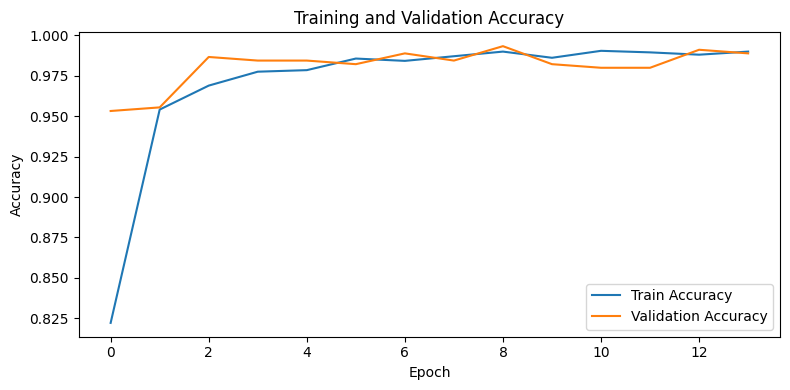

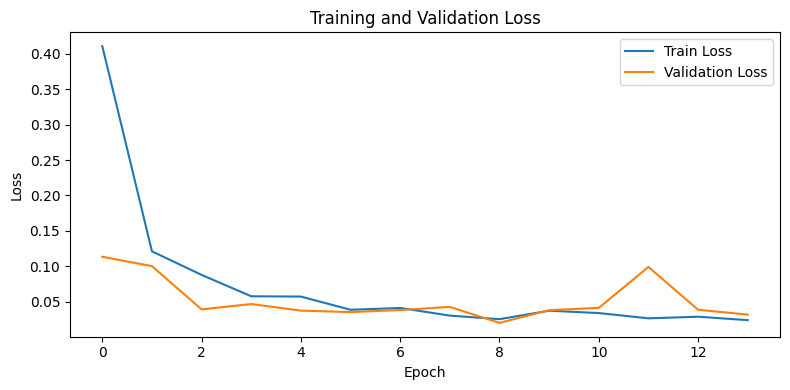

In [210]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

# 테스트셋 분류 리포트 및 Confusion Matrix

28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step

분류 리포트
              precision    recall  f1-score   support

  Non_Hornet       0.99      0.98      0.98       298
      Hornet       0.95      0.97      0.96       149

    accuracy                           0.98       447
   macro avg       0.97      0.97      0.97       447
weighted avg       0.98      0.98      0.98       447

🔥 Hornet Recall: 0.9732


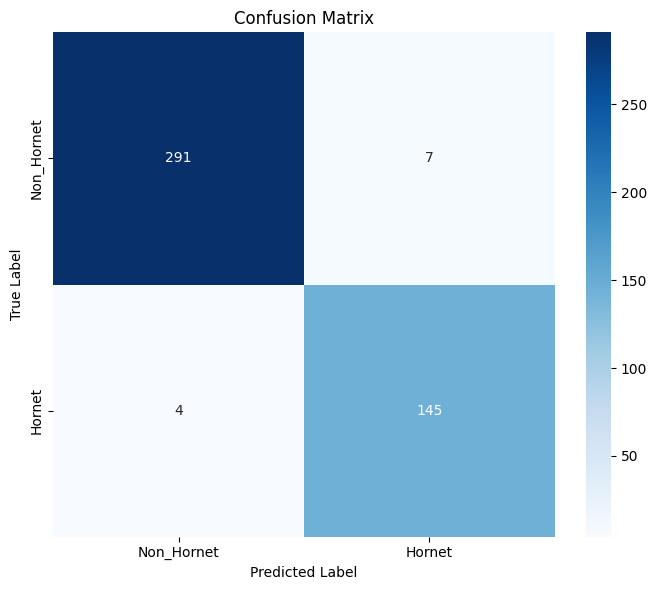

In [211]:
# 테스트셋 전체에 대해 클래스별 확률을 예측
from sklearn.metrics import recall_score


pred_probs = model.predict(test_generator)

# 가장 큰 확률을 갖는 인덱스를 최종 예측 클래스로 사용
pred_classes = np.argmax(pred_probs, axis=1)

# 실제 정답 라벨
true_classes = test_generator.classes

# 클래스 이름 목록
class_labels = list(test_generator.class_indices.keys())

print_section_title("분류 리포트")
print(classification_report(
    true_classes,
    pred_classes,
    target_names=class_labels,
    zero_division=0
))

hornet_recall = recall_score(true_classes, pred_classes, pos_label=1)
print(f'🔥 Hornet Recall: {hornet_recall:.4f}')

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## threshold 적용

In [212]:
hornet_prob = pred_probs[:, 1]
threshold = 0.4

y_pred_custom = (hornet_prob >= threshold).astype(int)

print("\n[Threshold 적용 결과]")
print(classification_report(
    true_classes,
    y_pred_custom,
    target_names=['Non_Hornet', 'Hornet']
))

hornet_recall_custom = recall_score(true_classes, y_pred_custom, pos_label=1)
print(f'Hornet Recall (threshold): {hornet_recall_custom:.4f}')


[Threshold 적용 결과]
              precision    recall  f1-score   support

  Non_Hornet       0.99      0.98      0.98       298
      Hornet       0.95      0.97      0.96       149

    accuracy                           0.98       447
   macro avg       0.97      0.97      0.97       447
weighted avg       0.98      0.98      0.98       447

Hornet Recall (threshold): 0.9732


# 예측용 오디오 분석/시각화 함수

In [213]:
def visualize_audio_analysis(audio_path, predicted_class=None, probs_dict=None):
    """
    신규 입력 오디오에 대해 waveplot, FFT, spectrogram을 순차적으로 시각화
    """

    # 오디오를 로드
    y, sr = load_audio_file(audio_path)

    # 파일명만 표시용으로 추출
    file_name = os.path.basename(audio_path)

    # 1) waveplot 시각화
    plt.figure(figsize=(14, 4))
    librosa.display.waveshow(y, sr=sr)
    plt.title(f"Input Audio Waveform - {file_name}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    ()

    # 2) FFT 시각화
    fft_vals = np.fft.fft(y)
    magnitude = np.abs(fft_vals)
    freqs = np.fft.fftfreq(len(magnitude), d=1 / sr)
    positive_freqs = freqs[:len(freqs) // 2]
    positive_magnitude = magnitude[:len(magnitude) // 2]

    plt.figure(figsize=(14, 4))
    plt.plot(positive_freqs, positive_magnitude)
    plt.title(f"Input Audio FFT Spectrum - {file_name}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.xlim(0, 8000)
    plt.tight_layout()
    ()

    # 3) Spectrogram 시각화
    stft = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH)
    spectrogram = np.abs(stft)
    spectrogram_db = librosa.amplitude_to_db(spectrogram, ref=np.max)

    plt.figure(figsize=(12, 5))
    librosa.display.specshow(
        spectrogram_db,
        sr=sr,
        hop_length=HOP_LENGTH,
        x_axis='time',
        y_axis='log'
    )
    plt.colorbar(format='%+2.0f dB')
    if predicted_class is None:
        plt.title(f"Input Audio Spectrogram - {file_name}")
    else:
        plt.title(f"Input Audio Spectrogram - {file_name}\nPredicted: {predicted_class}")
    plt.tight_layout()
    ()

    # 4) 예측 확률 막대그래프
    if probs_dict is not None:
        probs_df = pd.DataFrame({
            "Class": list(probs_dict.keys()),
            "Probability": list(probs_dict.values())
        }).sort_values("Probability", ascending=False)

        plt.figure(figsize=(8, 4))
        sns.barplot(data=probs_df, x="Class", y="Probability")
        plt.title(f"Prediction Probability - {file_name}")
        plt.xlabel("Instrument Class")
        plt.ylabel("Probability")
        plt.xticks(rotation=30)
        plt.ylim(0, 1.0)
        plt.tight_layout()
        plt.show()

# 추론 시 단일 파일 1번 판단 말고 연속 window voting 적용
- 지금 주력 평가용 핵심 함수는 아니다

In [214]:
from tensorflow.keras.preprocessing import image

def load_and_preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

In [215]:
def split_audio_windows(audio_path, sr=32768, window_sec=2, hop_sec=1):
    y, _ = librosa.load(audio_path, sr=sr)

    window_size = int(sr * window_sec)
    hop_size = int(sr * hop_sec)

    windows = []

    if len(y) < window_size:
        padded = np.pad(y, (0, window_size - len(y)))
        windows.append(padded)
        return windows

    for start in range(0, len(y) - window_size + 1, hop_size):
        window = y[start:start + window_size]
        windows.append(window)

    return windows

In [216]:
import os
import soundfile as sf

def predict_window(window, model, temp_dir, idx):
    temp_wav = os.path.join(temp_dir, f'temp_window_{idx}.wav')
    temp_img = os.path.join(temp_dir, f'temp_window_{idx}.png')

    sf.write(temp_wav, window, 32768)

    save_spectrogram_image(temp_wav, temp_img)

    img = load_and_preprocess_image(temp_img)
    pred = model.predict(img, verbose=0)

    if os.path.exists(temp_wav):
        os.remove(temp_wav)
    if os.path.exists(temp_img):
        os.remove(temp_img)

    return pred[0]

In [217]:
def predict_with_voting(audio_path, model, temp_dir, threshold=0.5):
    windows = split_audio_windows(audio_path)

    preds = []

    for i, window in enumerate(windows):
        pred = predict_window(window, model, temp_dir, i)
        preds.append(pred)

    preds = np.array(preds)

    hornet_probs = preds[:, 1]

    avg_prob = np.mean(hornet_probs)
    vote_ratio = np.mean(hornet_probs >= threshold)

    return {
        'avg_prob': avg_prob,
        'vote_ratio': vote_ratio,
        'hornet_probs': hornet_probs,
        'num_windows': len(windows)
    }

In [263]:
TEMP_DIR = r'C:\Users\hoons\OneDrive\바탕 화면\휴먼교육 실습\휴먼 프로젝트\temp_predict'
ensure_directory_exists(TEMP_DIR)

audio_path = r"C:\Users\hoons\OneDrive\바탕 화면\휴먼교육 실습\휴먼 프로젝트\동적 소음 검증용\장수말벌의 의리, 장수 말벌의 독은 꿀벌의 40배, 6마리만 공격하면 벌통 하나의 수만마리 꿀벌을 다 죽일수 있어요 , 그러나 잡기 쉬워요  한 마리만 잡아 끈끈이에 붙이면 잡혀요.mp3"
result = predict_with_voting(audio_path, model, TEMP_DIR, threshold=0.5)

for i, prob in enumerate(result['hornet_probs']):
    print(f'window {i+1}: Hornet 확률 = {prob:.4f}')

print(f'총 window 개수: {result["num_windows"]}')
print(f'Hornet 평균 확률: {result["avg_prob"]:.4f}')
print(f'Hornet voting 비율: {result["vote_ratio"]:.4f}')

if result['vote_ratio'] >= 0.4:
    print('최종 판단: Hornet detected')
else:
    print('최종 판단: Non-Hornet')

window 1: Hornet 확률 = 0.9889
window 2: Hornet 확률 = 0.9611
window 3: Hornet 확률 = 0.9960
window 4: Hornet 확률 = 0.9983
window 5: Hornet 확률 = 0.8436
window 6: Hornet 확률 = 0.0372
window 7: Hornet 확률 = 0.9535
window 8: Hornet 확률 = 0.9843
총 window 개수: 8
Hornet 평균 확률: 0.8454
Hornet voting 비율: 0.8750
최종 판단: Hornet detected


<Figure size 640x480 with 0 Axes>

# 신규 오디오 예측 함수

In [219]:
def predict_instrument_from_audio_absolute_path(audio_path, model, class_indices, save_temp_image=False):
    """
    절대경로로 지정한 신규 오디오 파일을 읽어와 CNN으로 예측한다.

    기능:
    - 입력 파일 유효성 검사
    - spectrogram 임시 이미지 생성
    - 모델 추론
    - 예측 클래스 및 확률 반환
    - 입력 오디오 waveplot / FFT / spectrogram / 확률 시각화 수행
    """

    # 입력값 타입 검증
    if not isinstance(audio_path, str):
        raise TypeError("[오류] audio_path는 문자열이어야 합니다.")

    # 절대경로인지 확인한다. 사용자 요청 조건을 강제하기 위한 검증.
    if not os.path.isabs(audio_path):
        raise ValueError(f"[오류] 신규 오디오 예측 경로는 절대경로여야 합니다: {audio_path}")

    # 실제 파일 존재 여부 확인
    if not os.path.exists(audio_path):
        raise FileNotFoundError(f"[오류] 신규 예측용 오디오 파일이 존재하지 않습니다: {audio_path}")

    # 모델 유효성 확인
    if model is None:
        raise ValueError("[오류] 학습된 모델이 없습니다.")

    # 클래스 인덱스 매핑 확인
    if not isinstance(class_indices, dict) or len(class_indices) == 0:
        raise ValueError("[오류] class_indices가 비어 있거나 유효하지 않습니다.")

    # 임시 spectrogram 이미지가 남아 있으면 삭제
    if os.path.exists(TEMP_PREDICT_IMAGE_PATH):
        os.remove(TEMP_PREDICT_IMAGE_PATH)

    # 신규 오디오를 spectrogram 이미지로 변환
    save_spectrogram_image(audio_path, TEMP_PREDICT_IMAGE_PATH)

    # 임시 이미지가 실제 생성되었는지 확인
    if not os.path.exists(TEMP_PREDICT_IMAGE_PATH):
        raise FileNotFoundError("[오류] 예측용 임시 spectrogram 이미지 생성에 실패했습니다.")

    # 저장된 이미지를 열어 RGB 변환
    img = Image.open(TEMP_PREDICT_IMAGE_PATH).convert("RGB")

    # 모델 입력 크기로 리사이즈
    img = img.resize((IMG_WIDTH, IMG_HEIGHT))

    # numpy 배열로 변환 후 0~1 범위로 정규화
    img_array = np.array(img).astype("float32") / 255.0

    # (H, W, C) -> (1, H, W, C)로 배치 축을 추가
    img_array = np.expand_dims(img_array, axis=0)

    # 모델 추론을 수행한다.
    probs = model.predict(img_array, verbose=0)[0]

    # 최대 확률 클래스 인덱스를 찾는다.
    pred_idx = int(np.argmax(probs))

    # index -> class 역매핑 생성
    idx_to_class_local = {v: k for k, v in class_indices.items()}

    # 예측 클래스 이름
    predicted_class = idx_to_class_local[pred_idx]

    # 클래스별 확률 dict 생성
    probs_dict = {idx_to_class_local[i]: float(probs[i]) for i in range(len(probs))}

    # 예측용 spectrogram 이미지 자체를 보여준다.
    plt.figure(figsize=(5, 5))
    plt.imshow(Image.open(TEMP_PREDICT_IMAGE_PATH))
    plt.title(f"Prediction Spectrogram\nPredicted: {predicted_class}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # 입력 오디오의 wave/FFT/spectrogram/확률을 함께 시각화
    visualize_audio_analysis(
        audio_path=audio_path,
        predicted_class=predicted_class,
        probs_dict=probs_dict
    )

    # 임시 저장을 원하지 않으면 삭제
    if not save_temp_image and os.path.exists(TEMP_PREDICT_IMAGE_PATH):
        os.remove(TEMP_PREDICT_IMAGE_PATH)

    return predicted_class, probs_dict

# 신규 오디오 절대경로 입력 예시


신규 오디오 예측 준비
절대경로 입력 예시: C:\Users\hoons\OneDrive\바탕 화면\휴먼교육 실습\휴먼 프로젝트\동적 소음 검증용\벌 소리 ASMR #양봉  (졸 수 있음).mp3


<Figure size 640x480 with 0 Axes>

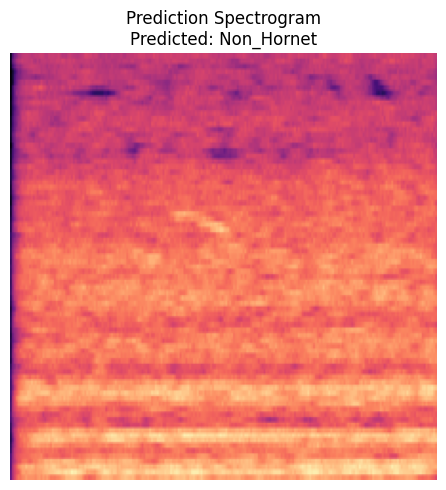

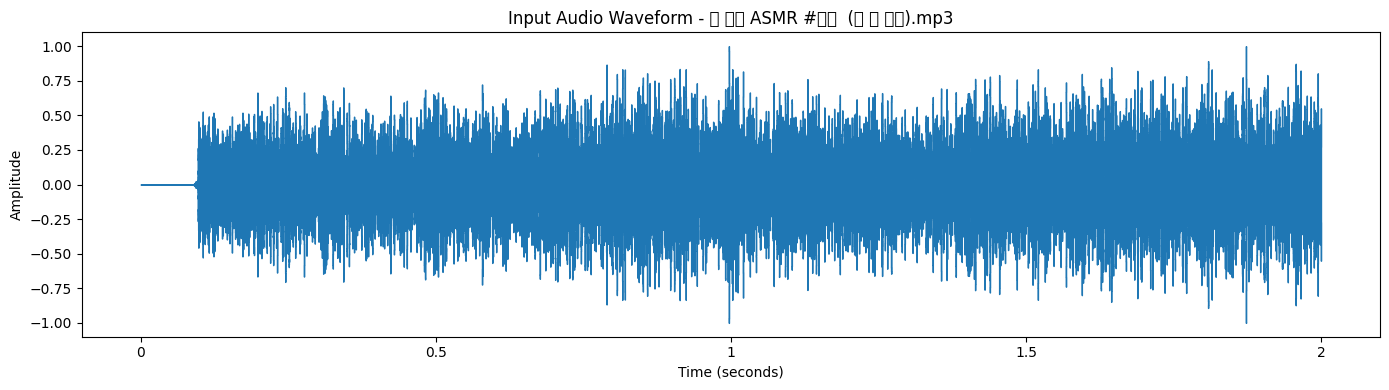

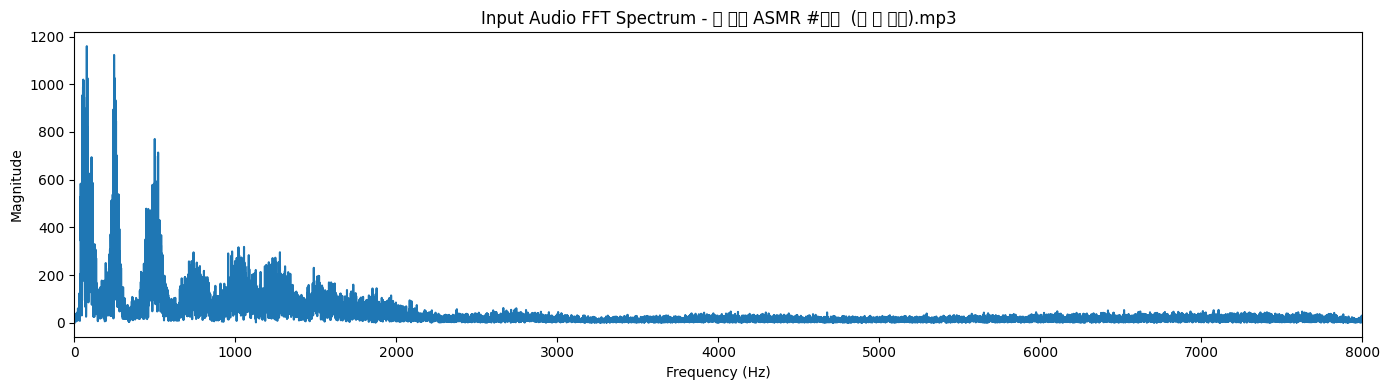

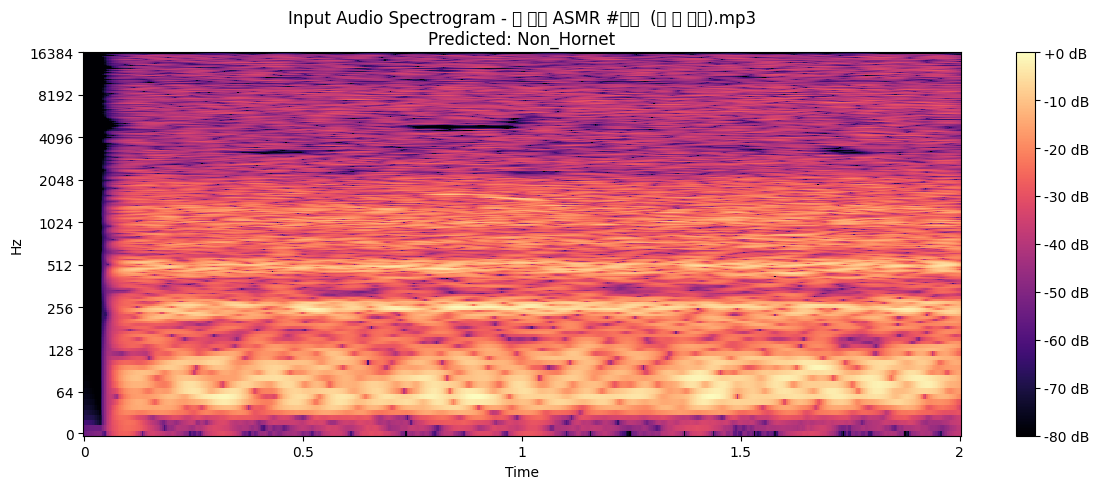

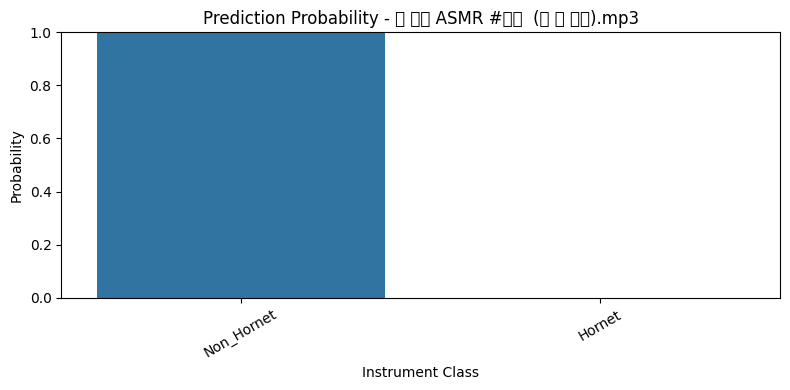

예측된 클래스: Non_Hornet
클래스별 확률:
  Non_Hornet: 1.0000
  Hornet: 0.0000


In [220]:
NEW_AUDIO_ABSOLUTE_PATH = os.path.abspath(r'C:\Users\hoons\OneDrive\바탕 화면\휴먼교육 실습\휴먼 프로젝트\동적 소음 검증용\벌 소리 ASMR #양봉  (졸 수 있음).mp3')

print_section_title("신규 오디오 예측 준비")
print('절대경로 입력 예시:', NEW_AUDIO_ABSOLUTE_PATH)

if os.path.isabs(NEW_AUDIO_ABSOLUTE_PATH):
    predicted_class, probs_dict = predict_instrument_from_audio_absolute_path(
        audio_path=NEW_AUDIO_ABSOLUTE_PATH,
        model=model,
        class_indices=train_generator.class_indices,
        save_temp_image=False
    )

    print(f"예측된 클래스: {predicted_class}")
    print("클래스별 확률:")
    for cls, prob in sorted(probs_dict.items(), key=lambda x: x[1], reverse=True):
        print(f"  {cls}: {prob:.4f}")
else:
    print("[오류] NEW_AUDIO_ABSOLUTE_PATH 변수에 절대경로를 입력해주세요.")

# 이미지 XAI 중요도 관측
이 섹션에서는 Grad-CAM을 사용해 모델이 스펙트로그램의 어느 영역에 상대적으로 주목했는지 시각적으로 확인한다.
단, 이는 모델의 내부 판단 경향을 보여주는 참고용 시각화이며, 절대적인 중요도를 의미하지는 않는다.

## 마지막 Conv2D 레이어 자동 찾기 함수

In [221]:
# def get_last_conv_layer_name(model):
#     for layer in reversed(model.layers):
#         if isinstance(layer, tf.keras.layers.Conv2D):
#             return layer.name
#     raise ValueError('Conv2D 레이어를 찾지 못했습니다.')

In [222]:
# dummy_input = np.zeros((1, IMG_HEIGHT, IMG_WIDTH, 3), dtype=np.float32)
# _ = model(dummy_input)

# dummy_input = np.zeros((1, IMG_HEIGHT, IMG_WIDTH, 3), dtype=np.float32)
# dummy_output = model(dummy_input, training=False)

# print("model.inputs:", model.inputs)
# print("model.outputs:", model.outputs)
# print("dummy_output shape:", dummy_output.shape)

# last_conv_layer_name = get_last_conv_layer_name(model)
# print("마지막 Conv 레이어:", last_conv_layer_name)

## Grad-CAM heatmap 생성 함수

In [223]:
# def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
#     # 마지막 conv layer 가져오기
#     last_conv_layer = model.get_layer(last_conv_layer_name)

#     # 입력 -> 마지막 conv 출력까지의 모델
#     last_conv_layer_model = tf.keras.models.Model(
#         inputs=model.inputs,
#         outputs=last_conv_layer.output
#     )

#     # 마지막 conv layer 이후의 classifier 부분을 따로 실행
#     classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
#     x = classifier_input

#     passed_last_conv = False
#     for layer in model.layers:
#         if layer.name == last_conv_layer_name:
#             passed_last_conv = True
#             continue
#         if passed_last_conv:
#             x = layer(x)

#     classifier_model = tf.keras.models.Model(classifier_input, x)

#     with tf.GradientTape() as tape:
#         conv_outputs = last_conv_layer_model(img_array, training=False)
#         tape.watch(conv_outputs)

#         predictions = classifier_model(conv_outputs, training=False)

#         if pred_index is None:
#             pred_index = tf.argmax(predictions[0])

#         class_channel = predictions[:, pred_index]

#     grads = tape.gradient(class_channel, conv_outputs)

#     if grads is None:
#         raise ValueError('Grad-CAM gradient가 None입니다. 마지막 Conv 레이어 이름 또는 모델 구조를 다시 확인하세요.')

#     pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

#     conv_outputs = conv_outputs[0]
#     heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
#     heatmap = tf.squeeze(heatmap)

#     heatmap = tf.maximum(heatmap, 0)
#     heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

#     return heatmap.numpy(), int(pred_index), predictions.numpy()[0]

## heatmap을 원본 이미지 위에 덮는 함수

In [224]:
# def overlay_gradcam_on_image(img_path, heatmap, alpha=0.4):
#     import matplotlib.cm as mpl_cm

#     img = Image.open(img_path).convert('RGB')
#     img = np.array(img)

#     heatmap = np.uint8(255 * heatmap)
#     jet = mpl_cm.get_cmap('jet')
#     jet_colors = jet(np.arange(256))[:, :3]
#     jet_heatmap = jet_colors[heatmap]

#     jet_heatmap = Image.fromarray(np.uint8(jet_heatmap * 255))
#     jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
#     jet_heatmap = np.array(jet_heatmap)

#     superimposed_img = np.uint8((1 - alpha) * img + alpha * jet_heatmap)

#     return img, jet_heatmap, superimposed_img

## spectrogram png 하나에 대해 Grad-CAM 보는 함수

In [225]:
# def save_gradcam_result_from_image(img_path, model, save_path, class_names=None, target_class_index=None):
#     if class_names is None:
#         class_names = ['Non_Hornet', 'Hornet']

#     img_array = load_and_preprocess_image(img_path)
#     last_conv_layer_name = get_last_conv_layer_name(model)

#     heatmap, pred_index, pred_probs = make_gradcam_heatmap(
#         img_array,
#         model,
#         last_conv_layer_name,
#         pred_index=target_class_index
#     )

#     original_img, heatmap_img, overlay_img = overlay_gradcam_on_image(img_path, heatmap)

#     pred_class_name = class_names[pred_index]
#     prob_text = ' | '.join([f'{class_names[i]}: {pred_probs[i]:.3f}' for i in range(len(class_names))])
#     base_name = os.path.basename(img_path)

#     save_dir = os.path.dirname(save_path)
#     if save_dir != '':
#         ensure_directory_exists(save_dir)

#     fig = plt.figure(figsize=(12, 4))

#     plt.subplot(1, 3, 1)
#     plt.imshow(original_img)
#     plt.title(f'Original\n{base_name}')
#     plt.axis('off')

#     plt.subplot(1, 3, 2)
#     plt.imshow(heatmap, cmap='jet')
#     plt.title(f'Grad-CAM\nPred: {pred_class_name}')
#     plt.axis('off')

#     plt.subplot(1, 3, 3)
#     plt.imshow(overlay_img)
#     plt.title(prob_text)
#     plt.axis('off')

#     plt.tight_layout()
#     plt.savefig(save_path, dpi=200, bbox_inches='tight')
#     plt.close(fig)

In [226]:
# def save_gradcam_results_for_all_images(spec_dir, gradcam_dir, model, class_names=None, target_class_index=None):
#     if class_names is None:
#         class_names = ['Non_Hornet', 'Hornet']

#     safe_remove_path(gradcam_dir)
#     ensure_directory_exists(gradcam_dir)

#     print_section_title('Grad-CAM 결과 이미지 생성 중...')

#     total_count = 0

#     for cls in CLASSES:
#         class_spec_dir = os.path.join(spec_dir, cls)
#         class_gradcam_dir = os.path.join(gradcam_dir, cls)

#         ensure_directory_exists(class_gradcam_dir)

#         img_files = glob.glob(os.path.join(class_spec_dir, '*.png'))
#         print(f'{cls}: {len(img_files)}개 이미지 처리 중...')

#         for img_path in img_files:
#             base_name = os.path.splitext(os.path.basename(img_path))[0]
#             save_path = os.path.join(class_gradcam_dir, f'{base_name}_gradcam.png')

#             save_gradcam_result_from_image(
#                 img_path=img_path,
#                 model=model,
#                 save_path=save_path,
#                 class_names=class_names,
#                 target_class_index=target_class_index
#             )

#             total_count += 1

#     print(f'Grad-CAM 결과 저장 완료: 총 {total_count}개')
#     print(f'저장 위치: {gradcam_dir}')

In [227]:
# GRADCAM_DIR = r'C:\Users\hoons\OneDrive\바탕 화면\휴먼교육 실습\휴먼 프로젝트\gradcam_results'

# save_gradcam_results_for_all_images(
#     spec_dir=SPEC_DIR,
#     gradcam_dir=GRADCAM_DIR,
#     model=model,
#     class_names=['Non_Hornet', 'Hornet']
# )

## wav 파일 하나로부터 spectrogram 만들고 Grad-CAM 보는 함수

In [228]:
# def show_gradcam_from_image(img_path, model, class_names=None, target_class_index=None):
#     img_array = load_and_preprocess_image(img_path)

#     last_conv_layer_name = get_last_conv_layer_name(model)

#     heatmap, pred_index, pred_probs = make_gradcam_heatmap(
#         img_array,
#         model,
#         last_conv_layer_name,
#         pred_index=target_class_index
#     )

#     original_img, heatmap_img, overlay_img = overlay_gradcam_on_image(img_path, heatmap)

#     if class_names is None:
#         class_names = ['Non_Hornet', 'Hornet']

#     print(f'마지막 Conv 레이어: {last_conv_layer_name}')
#     print('예측 확률:')
#     for i, prob in enumerate(pred_probs):
#         print(f'  {class_names[i]}: {prob:.4f}')
#     print(f'예측 클래스: {class_names[pred_index]}')

#     plt.figure(figsize=(12, 4))

#     plt.subplot(1, 3, 1)
#     plt.imshow(original_img)
#     plt.title('Original Spectrogram')
#     plt.axis('off')

#     plt.subplot(1, 3, 2)
#     plt.imshow(heatmap, cmap='jet')
#     plt.title('Grad-CAM Heatmap')
#     plt.axis('off')

#     plt.subplot(1, 3, 3)
#     plt.imshow(overlay_img)
#     plt.title('Overlay')
#     plt.axis('off')

#     plt.tight_layout()
#     plt.show()

In [229]:
# def show_gradcam_from_audio(audio_path, model, temp_dir, class_names=None, target_class_index=None):
#     ensure_directory_exists(temp_dir)

#     base_name = os.path.splitext(os.path.basename(audio_path))[0]
#     temp_img_path = os.path.join(temp_dir, f'{base_name}_gradcam.png')

#     save_spectrogram_image(audio_path, temp_img_path)

#     show_gradcam_from_image(
#         temp_img_path,
#         model,
#         class_names=class_names,
#         target_class_index=target_class_index
#     )

### wav 파일로 바로 보기

In [230]:
# TEMP_DIR = r'C:\Users\hoons\OneDrive\바탕 화면\휴먼교육 실습\휴먼 프로젝트\temp_predict'
# ensure_directory_exists(TEMP_DIR)

# audio_path = r'C:\Users\hoons\OneDrive\바탕 화면\휴먼교육 실습\휴먼 프로젝트\audio\Hornet\your_test_file.wav'

# show_gradcam_from_audio(
#     audio_path=audio_path,
#     model=model,
#     temp_dir=TEMP_DIR,
#     class_names=['Non_Hornet', 'Hornet']
# )

### Bee 파일인데 Hornet으로 오탐한 경우
- 모델이 저주파 전체 밝기만 보는지
- 특정 수평 band를 보는지
- 세로 줄 같은 일시적 잡음을 보는지

In [231]:
# audio_path = r'C:\Users\hoons\OneDrive\바탕 화면\휴먼교육 실습\휴먼 프로젝트\동적 소음 검증용\꿀벌소리.mp3'

# show_gradcam_from_audio(
#     audio_path=audio_path,
#     model=model,
#     temp_dir=TEMP_DIR,
#     class_names=['Non_Hornet', 'Hornet'],
#     target_class_index=1
# )

### 사람 목소리 파일인데 Hornet으로 뜬 경우
- 포먼트 구조나 연속적인 하모닉 줄을 Hornet으로 착각하는지
- 특정 저주파 영역만 과하게 보고 있는지

In [232]:
# audio_path = r'...사람 목소리 파일 경로...'

# show_gradcam_from_audio(
#     audio_path=audio_path,
#     model=model,
#     temp_dir=TEMP_DIR,
#     class_names=['Non_Hornet', 'Hornet'],
#     target_class_index=1
# )

### 진짜 Hornet 파일
- Hornet일 때와 Bee 오탐일 때 보는 위치가 비슷한지 다른지

In [233]:
# audio_path = r'C:\Users\samsung\OneDrive\바탕 화면\휴먼 프로젝트\동적 소음 검증용\장수말벌 헬리콥터 소리.....mp3'

# show_gradcam_from_audio(
#     audio_path=audio_path,
#     model=model,
#     temp_dir=TEMP_DIR,
#     class_names=['Non_Hornet', 'Hornet'],
#     target_class_index=1
# )